In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import glob
import os
import sys
import unicodedata
import re
import warnings

from unidecode import unidecode

warnings.simplefilter(action='ignore', category=Warning)

fsize = 10
plt.rcParams.update({"font.size": fsize})
%config InlineBackend.figure_format = 'retina'

# Benchmark Database & Source Verification

Summary of the human-curated marker gene benchmark and verification of annotation quality:

1. **Benchmark summary**: record counts, cell types, genes, pairs
2. **Text/image split**: modality breakdown per dataset
3. **DEG overlap**: fraction of curated markers found in supplementary DEG lists
4. **Source verification**: source rationale found verbatim in manuscript
5. **Label alignment**: group and feature labels found within source rationale
6. **Evidence scale**: DEG vs human evidence counts per dataset

In [2]:
def norm_text(text):
    if not isinstance(text, str):
        try:
            text = str(text)
        except:
            return ""
    text = unicodedata.normalize("NFC", text)
    text = unidecode(text)
    char_map = {
        "\u2013": "-", "\u2014": "--", "\u2018": "'", "\u2019": "'",
        "\u201c": '"', "\u201d": '"', "\u2026": "...",
        "\u2022": "*", "\u00b7": ".", "\u00d7": "x", "\u00f7": "/",
        "\u2264": "<=", "\u2265": ">=", "\u2260": "!=",
        "\u2248": "~", "\u221e": "inf", "\u2202": "d", "\u222b": "integral",
        "\u2211": "sum", "\u220f": "product",
        "\u221a": "sqrt", "\u221d": "prop to", "\u2220": "angle",
        "\u25b3": "triangle", "\u25a1": "square",
        "\u2208": "in", "\u2209": "not in", "\u2282": "subset",
        "\u2283": "superset", "\u222a": "union",
        "\u2229": "intersect", "\u2286": "subseteq", "\u2287": "superseteq",
    }
    for char, replacement in char_map.items():
        text = text.replace(char, replacement)
    text = text.replace("\n", " ")
    text = re.sub(r"\s+", " ", text)
    return text

In [3]:
datasets = [
    "adipose_Emont2022",
    "adipose_Hildreth2021",
    "bone_He2021",
    "eye_Gautam2021",
    "lung_Adams2020",
    "ovary_Wagner2020",
    "testis_Shamis2020",
]

labels = {
    "adipose_Emont2022": "Adipose (Emont)",
    "adipose_Hildreth2021": "Adipose (Hildreth)",
    "bone_He2021": "Bone (He)",
    "eye_Gautam2021": "Eye (Gautam)",
    "lung_Adams2020": "Lung (Adams)",
    "ovary_Wagner2020": "Ovary (Wagner)",
    "testis_Shamis2020": "Testis (Shamis)",
}

# Load human evidence
hmn_dfs = []
for ds in datasets:
    df = pd.read_json(f"../data/{ds}/evidence_human/extracted.json")
    df["ds_name"] = ds
    hmn_dfs.append(df)
hmn = pd.concat(hmn_dfs)

# Load DEG evidence
deg_dfs = []
for ds in datasets:
    df = pd.read_json(f"../data/{ds}/evidence_deg/extracted.json")
    df["ds_name"] = ds
    deg_dfs.append(df)
deg = pd.concat(deg_dfs).dropna(subset=["feature_id"])

# Load manuscripts
papers = {}
for ds in datasets:
    fn = f"../data/{ds}/manuscript/manuscript.txt"
    with open(fn, "r") as f:
        papers[ds] = f.read()

print(f"Datasets: {len(datasets)}")
print(f"Human records: {len(hmn)}")
print(f"DEG records: {len(deg)}")
print(f"Manuscripts: {len(papers)}")

Datasets: 7
Human records: 2528
DEG records: 224084
Manuscripts: 7


## Benchmark summary

In [4]:
summary_rows = []
for ds in datasets:
    h = hmn.query(f"ds_name == '{ds}'")
    txt = h.query("source_type == 'text'")
    img = h.query("source_type == 'image'")
    d = deg.query(f"ds_name == '{ds}'")

    cts = h["group_name"].dropna().nunique()
    genes = h["feature_id"].dropna().nunique()
    pairs = h.dropna(subset=["group_name", "feature_id"]).drop_duplicates(
        subset=["group_name", "feature_id"]).shape[0]

    summary_rows.append({
        "dataset": labels[ds],
        "records": len(h),
        "text": len(txt),
        "image": len(img),
        "cell_types": cts,
        "genes": genes,
        "pairs": pairs,
        "deg_records": len(d),
        "deg_sources": d["data_id"].nunique(),
    })

summary = pd.DataFrame(summary_rows)

# Totals
total = {
    "dataset": "Total",
    "records": summary["records"].sum(),
    "text": summary["text"].sum(),
    "image": summary["image"].sum(),
    "cell_types": hmn["group_name"].dropna().nunique(),
    "genes": hmn["feature_id"].dropna().nunique(),
    "pairs": hmn.dropna(subset=["group_name", "feature_id"]).drop_duplicates(
        subset=["group_name", "feature_id"]).shape[0],
    "deg_records": summary["deg_records"].sum(),
    "deg_sources": deg["data_id"].nunique(),
}
summary = pd.concat([summary, pd.DataFrame([total])], ignore_index=True)
summary

,dataset,records,text,image,cell_types,genes,pairs,deg_records,deg_sources
0,Adipose (Emont),387,31,356,45,105,346,45814,6
1,Adipose (Hildreth),301,74,227,31,141,234,54893,4
2,Bone (He),825,498,327,27,75,370,7181,5
3,Eye (Gautam),514,31,483,32,94,251,32655,7
4,Lung (Adams),147,36,111,20,124,135,53744,8
5,Ovary (Wagner),139,59,80,7,62,58,17956,3
6,Testis (Shamis),215,148,67,19,125,171,11841,6
7,Total,2528,877,1651,168,641,1560,224084,39


In [5]:
# Markers per cell type (unique genes)
ct_genes = hmn.dropna(subset=["group_name", "feature_id"]).drop_duplicates(
    subset=["ds_name", "group_name", "feature_id"]
).groupby(["ds_name", "group_name"])["feature_id"].nunique()

print(f"Markers per cell type: median={ct_genes.median():.0f}, "
      f"min={ct_genes.min()}, max={ct_genes.max()}")

# Text-only, image-only, both modalities (at pair level)
txt_pairs = set(zip(
    hmn.query("source_type == 'text'").dropna(subset=["feature_id"])["group_name"],
    hmn.query("source_type == 'text'").dropna(subset=["feature_id"])["feature_id"]
))
img_pairs = set(zip(
    hmn.query("source_type == 'image'").dropna(subset=["feature_id"])["group_name"],
    hmn.query("source_type == 'image'").dropna(subset=["feature_id"])["feature_id"]
))
both = txt_pairs & img_pairs
txt_only = txt_pairs - img_pairs
img_only = img_pairs - txt_pairs
all_pairs = txt_pairs | img_pairs
print(f"\nUnique (cell type, gene) pairs with valid Ensembl IDs: {len(all_pairs)}")
print(f"  Image only: {len(img_only)} ({100*len(img_only)/len(all_pairs):.0f}%)")
print(f"  Text only:  {len(txt_only)} ({100*len(txt_only)/len(all_pairs):.0f}%)")
print(f"  Both:       {len(both)} ({100*len(both)/len(all_pairs):.0f}%)")

Markers per cell type: median=6, min=1, max=46

Unique (cell type, gene) pairs with valid Ensembl IDs: 1585
  Image only: 1158 (73%)
  Text only:  260 (16%)
  Both:       167 (11%)


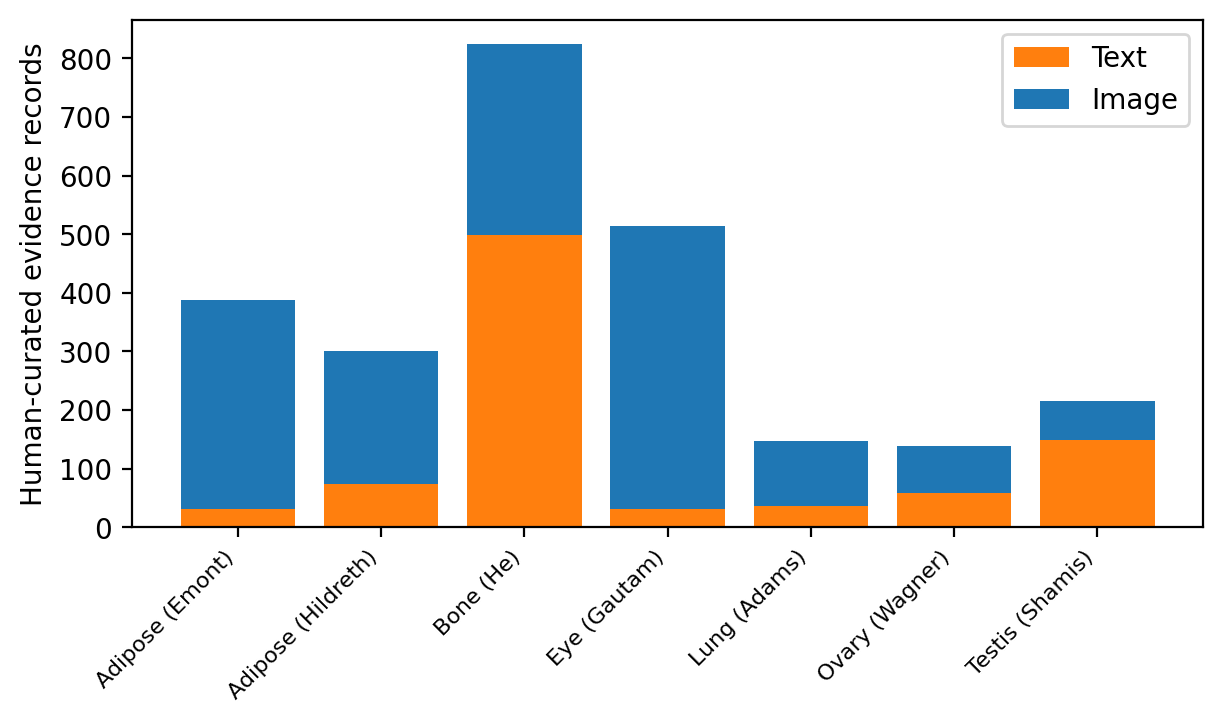

Text: 877/2528 (35%), Image: 1651/2528 (65%)


In [6]:
fig, ax = plt.subplots(figsize=(6, 3.5), constrained_layout=True)

src = summary.query("dataset != 'Total'")
x = np.arange(len(src))
ax.bar(x, src["text"], label="Text", color="#ff7f0e")
ax.bar(x, src["image"], bottom=src["text"], label="Image", color="#1f77b4")

ax.set(xticks=x, ylabel="Human-curated evidence records")
ax.set_xticklabels(src["dataset"], rotation=45, ha="right", fontsize=8)
ax.legend()

os.makedirs("figures", exist_ok=True)
fig.savefig("figures/fig_benchmark_text_image.pdf", bbox_inches="tight")
plt.show()

n_all = int(total["records"])
n_txt = int(total["text"])
n_img = int(total["image"])
print(f"Text: {n_txt}/{n_all} ({100*n_txt/n_all:.0f}%), Image: {n_img}/{n_all} ({100*n_img/n_all:.0f}%)")

## DEG overlap

Fraction of human-curated marker (cell type, gene) pairs that also appear in the DEG lists.

In [7]:
overlap_rows = []
for ds in datasets:
    h = hmn.query(f"ds_name == '{ds}'").dropna(subset=["group_name", "feature_id"])
    d = deg.query(f"ds_name == '{ds}'").dropna(subset=["group_name", "feature_id"])

    h_pairs = set(zip(h["group_name"], h["feature_id"]))
    d_pairs = set(zip(d["group_name"], d["feature_id"]))

    shared = h_pairs & d_pairs
    overlap_rows.append({
        "dataset": labels[ds],
        "hmn_pairs": len(h_pairs),
        "deg_pairs": len(d_pairs),
        "shared": len(shared),
        "overlap_pct": 100 * len(shared) / len(h_pairs) if h_pairs else 0,
    })

overlap_df = pd.DataFrame(overlap_rows)
overlap_df

,dataset,hmn_pairs,deg_pairs,shared,overlap_pct
0,Adipose (Emont),346,43471,137,39.595376
1,Adipose (Hildreth),234,46357,221,94.444444
2,Bone (He),370,5382,65,17.567568
3,Eye (Gautam),251,24998,129,51.394422
4,Lung (Adams),135,34760,131,97.037037
5,Ovary (Wagner),58,14357,46,79.310345
6,Testis (Shamis),171,9663,140,81.871345


## Source rationale verification

For each human-curated text annotation, check whether the `source_rationale` appears verbatim in the manuscript (after text normalization).

In [8]:
tdf = hmn.query("source_type == 'text'").copy()
tdf["source_rationale"] = tdf["source_rationale"].apply(norm_text)

tdf["found_source_rationale"] = tdf.apply(
    lambda x: x["source_rationale"] in papers[x["ds_name"]]
    if x["ds_name"] in papers else False, axis=1
)

agg_sr = tdf.groupby("ds_name").agg(
    total=("found_source_rationale", "count"),
    found=("found_source_rationale", "sum"),
)
agg_sr["pct"] = 100 * agg_sr["found"] / agg_sr["total"]
agg_sr["dataset"] = agg_sr.index.map(labels)

# Total row
total_sr = pd.DataFrame([{
    "dataset": "Total",
    "total": agg_sr["total"].sum(),
    "found": agg_sr["found"].sum(),
    "pct": 100 * agg_sr["found"].sum() / agg_sr["total"].sum(),
}])
agg_sr = pd.concat([agg_sr.reset_index(drop=True), total_sr], ignore_index=True)
agg_sr[["dataset", "total", "found", "pct"]]

,dataset,total,found,pct
0,Adipose (Emont),31,31,100.000000
1,Adipose (Hildreth),74,74,100.000000
2,Bone (He),498,498,100.000000
3,Eye (Gautam),31,31,100.000000
4,Lung (Adams),36,36,100.000000
5,Ovary (Wagner),59,59,100.000000
6,Testis (Shamis),148,115,77.702703
7,Total,877,844,96.237172


## Label alignment

For each human-curated text annotation, verify that the `group_label` (cell type) and `feature_label` (gene) can be found within the `source_rationale` using subword token alignment (taln).

In [9]:
sys.path.insert(0, "verify")
from extract.extract import align_ng, norm_text as taln_norm, reconstruct_target_by_token

tdf_aln = hmn.query("source_type == 'text'").copy()

# Align group_label within source_rationale
tdf_aln["found_aln_group_label"] = tdf_aln.apply(
    lambda x: align_ng(x["source_rationale"], x["group_label"])[0], axis=1
)
tdf_aln["source_group_label"] = tdf_aln["found_aln_group_label"].apply(
    lambda x: reconstruct_target_by_token("", x[0] if len(x) > 0 else "")
)

# Align feature_label within source_rationale
tdf_aln["found_aln_feature_label"] = tdf_aln.apply(
    lambda x: align_ng(x["source_rationale"], x["feature_label"])[0], axis=1
)
tdf_aln["source_feature_label"] = tdf_aln["found_aln_feature_label"].apply(
    lambda x: reconstruct_target_by_token("", x[0] if len(x) > 0 else "")
)

# Compare normalized
tdf_aln["found_feature_label"] = tdf_aln["source_feature_label"].apply(taln_norm) == tdf_aln["feature_label"].apply(taln_norm)
tdf_aln["found_group_label"] = tdf_aln["source_group_label"].apply(taln_norm) == tdf_aln["group_label"].apply(taln_norm)

agg_lbl = tdf_aln.groupby("ds_name").agg(
    total=("found_feature_label", "count"),
    group_found=("found_group_label", "sum"),
    feature_found=("found_feature_label", "sum"),
)
agg_lbl["group_pct"] = 100 * agg_lbl["group_found"] / agg_lbl["total"]
agg_lbl["feature_pct"] = 100 * agg_lbl["feature_found"] / agg_lbl["total"]
agg_lbl["dataset"] = agg_lbl.index.map(labels)

# Total row
total_lbl = pd.DataFrame([{
    "dataset": "Total",
    "total": agg_lbl["total"].sum(),
    "group_found": agg_lbl["group_found"].sum(),
    "group_pct": 100 * agg_lbl["group_found"].sum() / agg_lbl["total"].sum(),
    "feature_found": agg_lbl["feature_found"].sum(),
    "feature_pct": 100 * agg_lbl["feature_found"].sum() / agg_lbl["total"].sum(),
}])
agg_lbl = pd.concat([agg_lbl.reset_index(drop=True), total_lbl], ignore_index=True)
agg_lbl[["dataset", "total", "group_found", "group_pct", "feature_found", "feature_pct"]]

,dataset,total,group_found,group_pct,feature_found,feature_pct
0,Adipose (Emont),31,22,70.967742,28,90.322581
1,Adipose (Hildreth),74,74,100.000000,74,100.000000
2,Bone (He),498,495,99.397590,498,100.000000
3,Eye (Gautam),31,29,93.548387,31,100.000000
4,Lung (Adams),36,36,100.000000,36,100.000000
5,Ovary (Wagner),59,59,100.000000,59,100.000000
6,Testis (Shamis),148,140,94.594595,147,99.324324
7,Total,877,855,97.491448,873,99.543900


## Evidence scale

Number of unique (cell type, gene) pairs per source type and dataset. DEG lists contain orders of magnitude more entries than the human-curated sets.

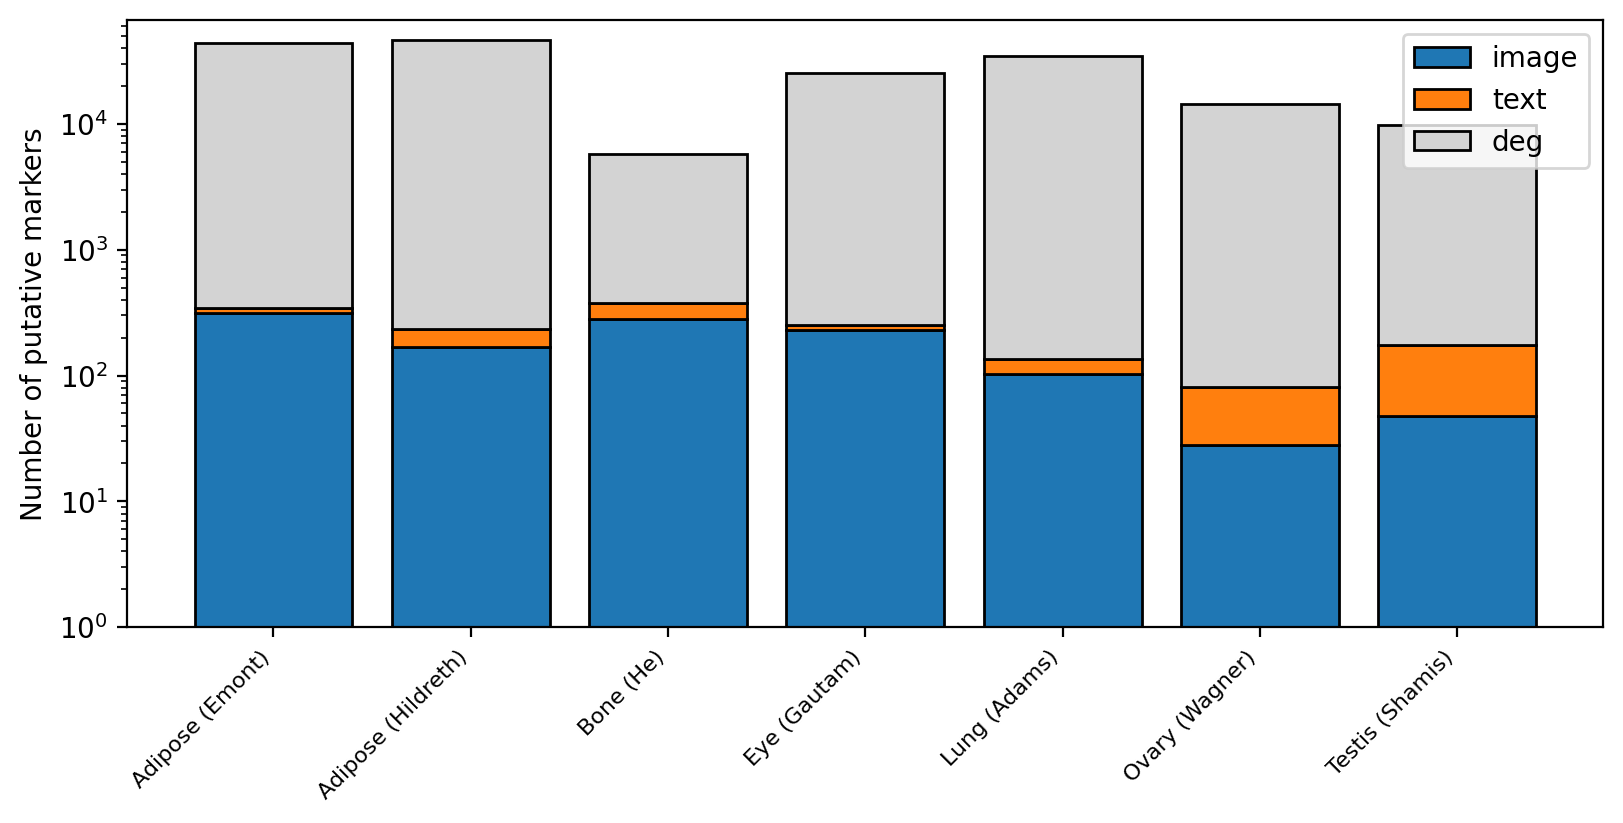

,ds_label,text,image,deg,total
0,Adipose (Emont),30,316,43389,43735
1,Adipose (Hildreth),67,168,46166,46401
2,Bone (He),96,282,5333,5711
3,Eye (Gautam),23,231,24902,25156
4,Lung (Adams),33,102,34667,34802
5,Ovary (Wagner),53,28,14321,14402
6,Testis (Shamis),128,48,9542,9718


In [10]:
def load_evidence(fn, ds_name):
    df = pd.read_json(fn)
    df["ds_name"] = ds_name
    df["group_name"] = df["group_name"].str.strip().str.upper()
    df["feature_id"] = df["feature_id"].str.strip().str.upper()
    return df

hmn_norm_dfs = []
for ds in datasets:
    hmn_norm_dfs.append(load_evidence(f"../data/{ds}/evidence_human/extracted.json", ds))
hmn_norm = pd.concat(hmn_norm_dfs)

deg_norm_dfs = []
for ds in datasets:
    deg_norm_dfs.append(load_evidence(f"../data/{ds}/evidence_deg/extracted.json", ds))
deg_norm = pd.concat(deg_norm_dfs)

hd = pd.concat([hmn_norm, deg_norm])
tbl = (hd.drop_duplicates(["ds_name", "group_name", "feature_id"])
       .groupby(["ds_name", "source_type"])[["group_name", "feature_id"]]
       .apply(lambda df: df.drop_duplicates().shape[0])
       .unstack(level="source_type", fill_value=0)
       .rename_axis(columns=None)
       .reset_index())

# Ensure all columns exist
for col in ["deg", "image", "text"]:
    if col not in tbl.columns:
        tbl[col] = 0
tbl["total"] = tbl["deg"] + tbl["image"] + tbl["text"]
tbl["ds_label"] = tbl["ds_name"].map(labels)

fig, ax = plt.subplots(figsize=(8, 4), constrained_layout=True)

xticks = np.arange(len(tbl))
h = np.zeros(len(tbl))
for src, color in [("image", "#1f77b4"), ("text", "#ff7f0e"), ("deg", "lightgrey")]:
    ax.bar(xticks, height=tbl[src].values, bottom=h, label=src, color=color, edgecolor="k")
    h += tbl[src].values

ax.set(yscale="log", xticks=xticks, ylabel="Number of putative markers", ylim=1)
ax.set_xticklabels(tbl["ds_label"], rotation=45, ha="right", fontsize=8)
ax.legend()

fig.savefig("figures/fig_benchmark_evidence_scale.pdf", bbox_inches="tight")
plt.show()

tbl[["ds_label", "text", "image", "deg", "total"]]

## Duplicate markers and LFC consistency

When the same cell type appears in multiple supplementary DEG tables within one study, marker genes may be shared across tables. We check whether the log-fold-change sign is consistent across sources.

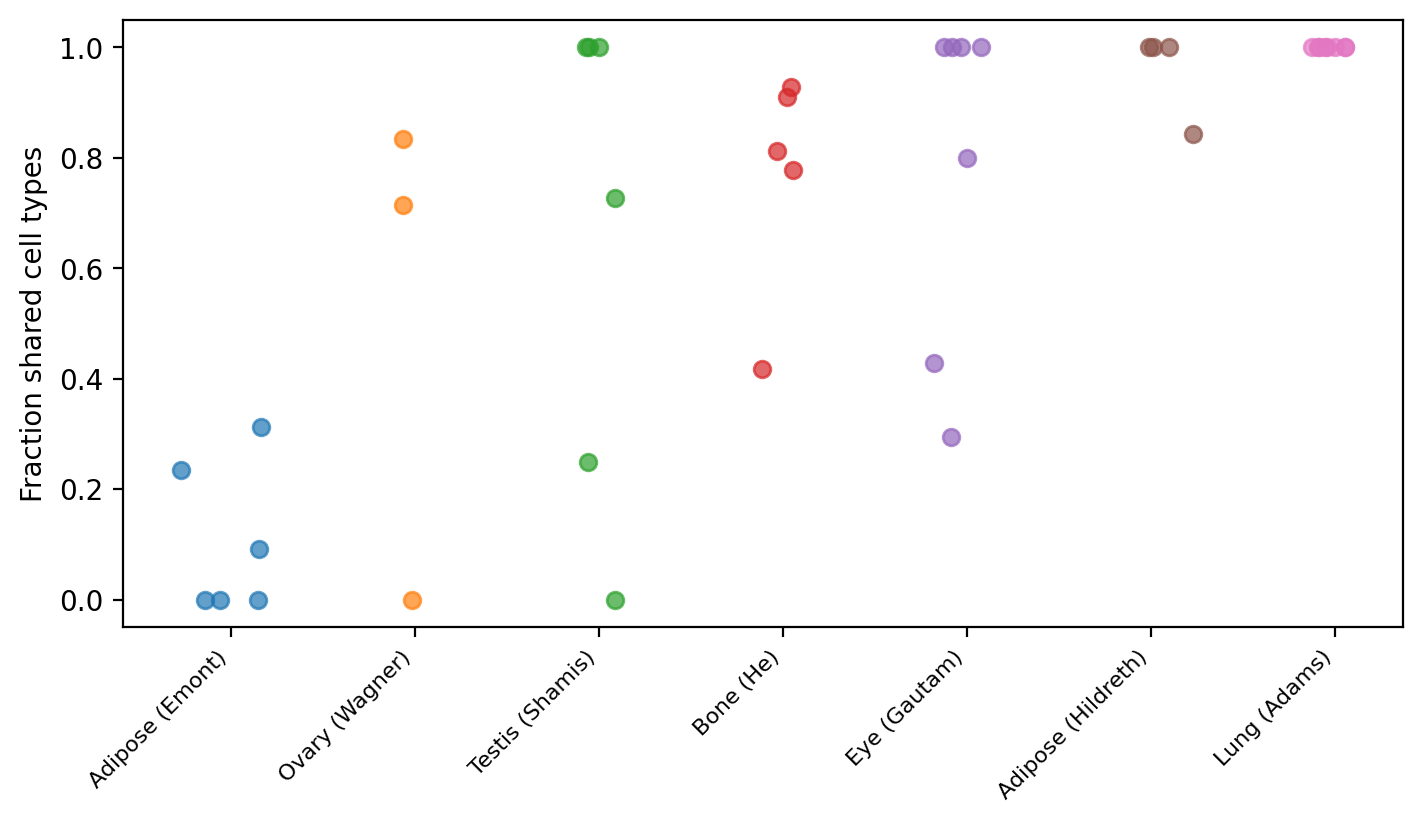

In [11]:
hmn_dup = hmn.dropna(subset=["group_name", "feature_id", "data_id"]).drop_duplicates(
    subset=["ds_name", "group_name", "feature_id", "data_id"]
)
deg_dup = deg.dropna(subset=["group_name", "feature_id"])

# Per-DEG file: fraction of cell types shared with other files in same dataset
deg_uniq = deg_dup.dropna(subset=["group_name"]).drop_duplicates(["ds_name", "data_id", "group_name"])
deg_sets = {
    ds: g.groupby("data_id")["group_name"].apply(set)
    for ds, g in deg_uniq.groupby("ds_name")
}

frac_rows = []
for ds, s in deg_sets.items():
    ids = list(s.index)
    if len(ids) == 1:
        frac_rows.append({"data_id": ids[0], "ds_name": ds, "frac_shared": 0.0})
    else:
        union_others = {i: set().union(*[s[j] for j in ids if j != i]) for i in ids}
        for i in ids:
            mine = s[i]
            others = union_others[i]
            shared = len(mine & others)
            total = len(mine)
            frac_rows.append({
                "data_id": i, "ds_name": ds,
                "frac_shared": shared / total if total > 0 else 0,
            })

frac_df = pd.DataFrame(frac_rows)

fig, ax = plt.subplots(figsize=(7, 4), constrained_layout=True)
groups = frac_df.groupby("ds_name")["frac_shared"].apply(list)
ds_names = groups.index.tolist()
all_y = [np.array(v) for v in groups.values]
asort = np.argsort([np.mean(i) for i in all_y])
all_y = [all_y[i] for i in asort]
ds_names = [ds_names[i] for i in asort]

for i, (x_name, yvals) in enumerate(zip(ds_names, all_y)):
    jitter = np.random.normal(0, 0.1, size=len(yvals))
    ax.scatter(np.full_like(yvals, i, dtype=float) + jitter, yvals, alpha=0.7)

ax.set(xticks=range(len(ds_names)), ylabel="Fraction shared cell types",
       ylim=(-0.05, 1.05))
ax.set_xticklabels([labels.get(n, n) for n in ds_names], rotation=45, ha="right", fontsize=8)

fig.savefig("figures/fig_benchmark_frac_shared.pdf", bbox_inches="tight")
plt.show()

In [12]:
# Match human markers to their DEG entries (exact data_id match)
ytrue = hmn_dup.merge(
    deg_dup, on=["ds_name", "group_name", "feature_id", "data_id"], how="inner"
)[["ds_name", "group_name", "feature_id", "metrics_logfc", "data_id"]]

# Cross-table matches (different data_ids)
ypred = hmn_dup.merge(
    deg_dup, on=["ds_name", "group_name", "feature_id"], how="inner",
    suffixes=("_hmn", "_deg")
)
ypred = ypred[ypred["data_id_hmn"] != ypred["data_id_deg"]][
    ["ds_name", "group_name", "feature_id", "metrics_logfc", "data_id_hmn"]
].rename(columns={"data_id_hmn": "data_id"})

# Compare LFC signs
other_degs = ytrue.merge(
    deg_dup[["ds_name", "group_name", "feature_id", "data_id", "metrics_logfc"]],
    on=["ds_name", "group_name", "feature_id"], how="inner",
    suffixes=("_true", "_other")
)
other_degs = other_degs[other_degs["data_id_true"] != other_degs["data_id_other"]].copy()
other_degs["sign_contradiction"] = np.sign(other_degs["metrics_logfc_true"]) != np.sign(other_degs["metrics_logfc_other"])

print(f"Total cross-table comparisons: {len(other_degs)}")
print(f"Sign contradictions (row-level): {other_degs['sign_contradiction'].sum()} "
      f"({other_degs['sign_contradiction'].mean():.1%})")

# Pair-level
pair_level = other_degs.groupby(
    ["ds_name", "group_name", "feature_id", "data_id_true"]
).agg(has_contradiction=("sign_contradiction", "any")).reset_index()

print(f"\nUnique ct/mg pairs with cross-table entries: {len(pair_level)}")
print(f"Pairs with at least one contradiction: {pair_level['has_contradiction'].sum()} "
      f"({pair_level['has_contradiction'].mean():.1%})")

# Per-paper breakdown
paper_stats = pair_level.groupby("ds_name").agg(
    total_pairs=("has_contradiction", "count"),
    contradicted=("has_contradiction", "sum"),
    rate=("has_contradiction", "mean"),
).reset_index()
paper_stats["dataset"] = paper_stats["ds_name"].map(labels)
paper_stats[["dataset", "total_pairs", "contradicted", "rate"]].sort_values("rate", ascending=False)

Total cross-table comparisons: 803
Sign contradictions (row-level): 53 (6.6%)

Unique ct/mg pairs with cross-table entries: 544
Pairs with at least one contradiction: 46 (8.5%)


,dataset,total_pairs,contradicted,rate
1,Adipose (Hildreth),80,31,0.387500
4,Lung (Adams),129,15,0.116279
0,Adipose (Emont),9,0,0.000000
2,Bone (He),31,0,0.000000
3,Eye (Gautam),157,0,0.000000
5,Ovary (Wagner),38,0,0.000000
6,Testis (Shamis),100,0,0.000000


## Cross-study nomenclature: Emont vs Hildreth adipose

Both adipose datasets profile human subcutaneous and visceral fat, yet use almost entirely different cell type names. This illustrates the nomenclature inconsistency that motivates extracting markers in the authors' own terms rather than mapping to a shared ontology a priori.

We compare:
- **PDGFRA** as a marker gene: Emont assigns it to all six ASPC subpopulations; Hildreth assigns it to "adipocyte precursor cell" and "preadipocyte"
- **Cell type name overlap**: how many of the combined cell type names are shared

In [ ]:
# --- PDGFRA across both adipose datasets ---
emont = hmn.query("ds_name == 'adipose_Emont2022'").copy()
hildreth = hmn.query("ds_name == 'adipose_Hildreth2021'").copy()

emont_pdgfra = emont[emont["feature_name"].str.upper() == "PDGFRA"]
hildreth_pdgfra = hildreth[hildreth["feature_name"].str.upper() == "PDGFRA"]

print("PDGFRA in Emont (human-curated):")
for _, r in emont_pdgfra.iterrows():
    print(f"  {r['group_name']:<45} source={r['source_type']:<6} data_id={r.get('data_id','')}")

print(f"\nPDGFRA in Hildreth (human-curated):")
for _, r in hildreth_pdgfra.iterrows():
    print(f"  {r['group_name']:<45} source={r['source_type']:<6} data_id={r.get('data_id','')}")

# --- DEG entries for PDGFRA ---
deg_emont = deg.query("ds_name == 'adipose_Emont2022'")
deg_hildreth = deg.query("ds_name == 'adipose_Hildreth2021'")

deg_pdgfra_e = deg_emont[deg_emont["feature_name"].str.upper() == "PDGFRA"]
deg_pdgfra_h = deg_hildreth[deg_hildreth["feature_name"].str.upper() == "PDGFRA"]

print(f"\nPDGFRA in Emont DEG tables: {len(deg_pdgfra_e)} entries")
for _, r in deg_pdgfra_e.iterrows():
    print(f"  {r['group_name']:<45} lfc={r.get('metrics_logfc',''):<8} data_id={r.get('data_id','')}")

print(f"\nPDGFRA in Hildreth DEG tables: {len(deg_pdgfra_h)} entries")
for _, r in deg_pdgfra_h.iterrows():
    print(f"  {r['group_name']:<45} lfc={r.get('metrics_logfc',''):<8} data_id={r.get('data_id','')}")

In [ ]:
# --- Cell type name overlap between the two adipose studies ---
emont_cts = set(emont["group_name"].str.strip().str.upper().unique())
hildreth_cts = set(hildreth["group_name"].str.strip().str.upper().unique())

shared_cts = sorted(emont_cts & hildreth_cts)
combined = emont_cts | hildreth_cts

print(f"Emont cell types:    {len(emont_cts)}")
print(f"Hildreth cell types: {len(hildreth_cts)}")
print(f"Combined:            {len(combined)}")
print(f"Shared:              {len(shared_cts)} / {len(combined)}")
print(f"\nShared cell type names:")
for ct in shared_cts:
    print(f"  {ct}")

print(f"\nEmont-only (sample):")
for ct in sorted(emont_cts - hildreth_cts)[:10]:
    print(f"  {ct}")

print(f"\nHildreth-only (sample):")
for ct in sorted(hildreth_cts - emont_cts)[:10]:
    print(f"  {ct}")